**实验目标：**
通过本实验，你将学习并实践信号处理中的三个重要任务：端点检测、基音周期检测以及 MFCC 特征提取。这些任务是语音信号处理和音频处理中的基础，对于语音识别和语音分析等应用至关重要。其中，端点检测、基音周期检测实验可以二选一，MFCC特征提取实验必须完成。

**实验方法：**

**1. 端点检测：**
  - 阅读端点检测的相关文献或资料，了解双门限法的原理和实现方式。
  - 使用 Python 编程语言，实现端点检测算法。
  - 在代码中设定合适的阈值来检测端点，你可以尝试不同的阈值来获取更好的效果。
  - 编写代码以可视化端点检测结果，将检测到的端点在原始信号上标出。

**2. 基音周期检测：**
  - 学习基音周期检测的原理，理解基音周期在语音信号中的重要性。
  - 使用 librosa 库或其他音频处理库加载音频数据。
  - 探索基音周期检测的方法，并尝试实现其中一种方法。你可以使用自相关函数或其他方法来检测基音周期。
  - 编写代码以可视化基音周期检测的结果，将检测到的基音周期在音频信号上标出。

**3. MFCC 特征提取：**
  - 了解 MFCC 特征在语音信号处理中的重要性以及其在语音识别中的应用。
  - 使用 librosa 库或其他音频处理库加载音频数据。
  - 实现 MFCC 特征提取算法。
  - 编写代码以可视化提取的 MFCC 特征，观察不同时间段内的特征变化。
  
**实验要求：**

录制一段音频，并开展上述实验，并可视化实验结果，并保存图片到本地。其中实验1和2可任选一个，实验3必做。

In [2]:
# #安装依赖库，可以跳过已安装的库
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip show numpy
%pip show matplotlib
%pip show scipy
%pip show pandas
%pip show pyaudio
%pip show wave
%pip show librosa
%pip show IPython
# 如果显示WARNING: Package(s) not found,则需要安装对应依赖库

Name: numpy
Version: 1.24.4
Summary: Fundamental package for array computing in Python
Home-page: https://www.numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: BSD-3-Clause
Location: /Users/ohhhhhmyking/Develop/anaconda3/envs/SSP/lib/python3.8/site-packages
Requires: 
Required-by: contourpy, librosa, matplotlib, numba, pandas, scikit-learn, scipy, soundfile, soxr
Note: you may need to restart the kernel to use updated packages.
Name: matplotlib
Version: 3.7.5
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: matplotlib-users@python.org
License: PSF
Location: /Users/ohhhhhmyking/Develop/anaconda3/envs/SSP/lib/python3.8/site-packages
Requires: contourpy, cycler, fonttools, importlib-resources, kiwisolver, numpy, packaging, pillow, pyparsing, python-dateutil
Required-by: 
Note: you may need to restart the kernel to use updated packages.
Name: scipy
Version: 1.10.1
Summary: Fundamental algorithms fo

我们鼓励大家使用自己录制的音频进行实验，下面是录制音频的简单示例，可根据自己设备的情况，对录制时长和采样率进行调整

In [1]:
#录制音频
def record_audio(duration):
    import pyaudio
    import wave

    CHUNK = 1024
    FORMAT = pyaudio.paInt16
    CHANNELS = 1
    RATE = 44100
    WAVE_OUTPUT_FILENAME = "demo.wav"

    p = pyaudio.PyAudio()

    stream = p.open(format=FORMAT,
                    channels=CHANNELS,
                    rate=RATE,
                    input=True,
                    frames_per_buffer=CHUNK)

    print("* 录音中...")

    frames = []

    for i in range(0, int(RATE / CHUNK * duration)):
        data = stream.read(CHUNK)
        frames.append(data)

    print("* 录音结束!")

    stream.stop_stream()
    stream.close()
    p.terminate()

    wf = wave.open(WAVE_OUTPUT_FILENAME, 'wb')
    wf.setnchannels(CHANNELS)
    wf.setsampwidth(p.get_sample_size(FORMAT))
    wf.setframerate(RATE)
    wf.writeframes(b''.join(frames))
    wf.close()
    
record_audio(duration=5) #录音5秒,并保存为demo.wav


* 录音中...
* 录音结束!


In [4]:
import IPython
IPython.display.Audio('demo.wav') #播放demo.wav

In [6]:
#读取音频
import numpy as np
import scipy.io.wavfile as wav
sr, signal = wav.read('demo.wav')
print('采样率：', sr)
print("信号长度：", signal.shapde)

采样率： 44100
信号长度： (220160,)


In [7]:
# 下面是一些会用到的音频处理函数
from speechlib import *
import os

实验1-1：基于双门限法的端点检测
需要补充下列方法: STEn、STZcr、vad_TwoThr

所有需要补充的代码都注释有TODO, 按要求补充即可

In [ ]:
def STEn(x: object, win: object, inc: object) -> object:
    """
    计算短时能量函数
    :param x: 语音信号
    :param win: 窗长
    :param inc: 帧移
    :return: 短时能量，即每一帧的能量
    """
    # TODO 需要补充
    # 1.分帧
    # 2.计算短时能量
    # 3.返回短时能量
    X = enframe(x, win, inc)
    s = np.multiply(X, X)
    return np.sum(s, axis=1)

    
def STZcr(x, win, inc, delta=0):
    """
    计算短时过零率
    :param x: 语音信号
    :param win: 窗长
    :param inc: 帧移
    :return: 短时过零率，即每一帧的过零率
    """
    # TODO 需要补充
    # 1.分帧
    # 2.计算短时过零率
    # 3.返回短时过零率
    absx = np.abs(x) # 取绝对值
    x = np.where(absx < delta, 0, x) # 小于delta的值置为0
    X = enframe(x, win, inc) # 分帧
    X1 = X[:, :-1] # 当前帧
    X2 = X[:, 1:] # 表示
    s = np.multiply(X1, X2) # 计算X1*X2
    sgn = np.where(s < 0, 1, 0) # 符号判断
    return np.mean(sgn, axis=1) # 计算过零率，取值范围[0, 1]
    
def vad_TwoThr(x, wlen, inc, NIS):
    """
    使用门限法进行端点检测
    :param x: 语音信号
    :param wlen: 分帧长度
    :param inc: 帧移
    :param NIS: 用于计算门限的无话段长度
    :return: 语音段的起始点和终止点，语音段数，语音段标记，非语音段标记，短时能量，短时过零率
    """
    maxsilence = 15
    minlen = 5
    status = 0
    y = enframe(x, wlen, inc)  # 补充：调用enframe方法进行分帧
    fn = y.shape[0] # 帧数
    amp = STEn(x, wlen, inc) # 计算短时能量, 需要在上方方法定义里补充
    zcr = STZcr(x, wlen, inc, delta=0.01) # 计算短时过零率, 需要在上方方法定义里补充
    ampth = np.mean(amp[:NIS]) # 计算短时能量的平均值
    zcrth = np.mean(zcr[:NIS]) # 计算短时过零率的平均值
    amp2 = 2 * ampth
    amp1 = 4 * ampth
    zcr2 = 2 * zcrth
    xn = 0
    count = np.zeros(fn)
    silence = np.zeros(fn)
    x1 = np.zeros(fn)
    x2 = np.zeros(fn)
    for n in range(fn):
    # 0-静音，1-可能开始，2-确定开始，3-语音段
    
        if status == 0 or status == 1:
            if amp[n] > amp1: # 语音段的起始点
                x1[xn] = n  # 补充：设置语音段起始点为当前帧
                status = 2
                silence[xn] = 0
                count[xn] += 1
            elif amp[n] > amp2 or zcr[n] > zcr2: # 可能开始
                status = 1
                count[xn] += 1
            else: # 静音
                status = 0
                count[xn] = 0
                x1[xn] = 0
                x2[xn] = 0

        elif status == 2:
            if amp[n] > amp2 or zcr[n] > zcr2:  # 补充：判断当前帧是否仍为语音段
                count[xn] += 1
            else:
                silence[xn] += 1
                if silence[xn] < maxsilence:
                    count[xn] += 1
                elif count[xn] < minlen:
                    status = 0
                    silence[xn] = 0
                    count[xn] = 0
                else:
                    status = 3
                    x2[xn] = x1[xn] + count[xn]
        elif status == 3:
            status = 0
            xn += 1
            count[xn] = 0
            silence[xn] = 0
            x1[xn] = 0
            x2[xn] = 0
    el = len(x1[:xn])
    if x1[el - 1] == 0:
        el -= 1
    if x2[el - 1] == 0:
        print('Error: Not find endding point!\n')
        x2[el] = fn
    SF = np.zeros(fn)
    NF = np.ones(fn)
    for i in range(el):
        SF[int(x1[i]):int(x2[i])] = 1 # 语音段标记
        NF[int(x1[i]):int(x2[i])] = 0 # 非语音段标记
    voiceseg = findSegment(np.where(SF == 1)[0]) # 找到语音段
    vsl = len(voiceseg.keys())
    return voiceseg, vsl, SF, NF, amp, zcr # 返回语音段的起始点和终止点，语音段数，语音段标记，非语音段标记，短时能量，短时过零率

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

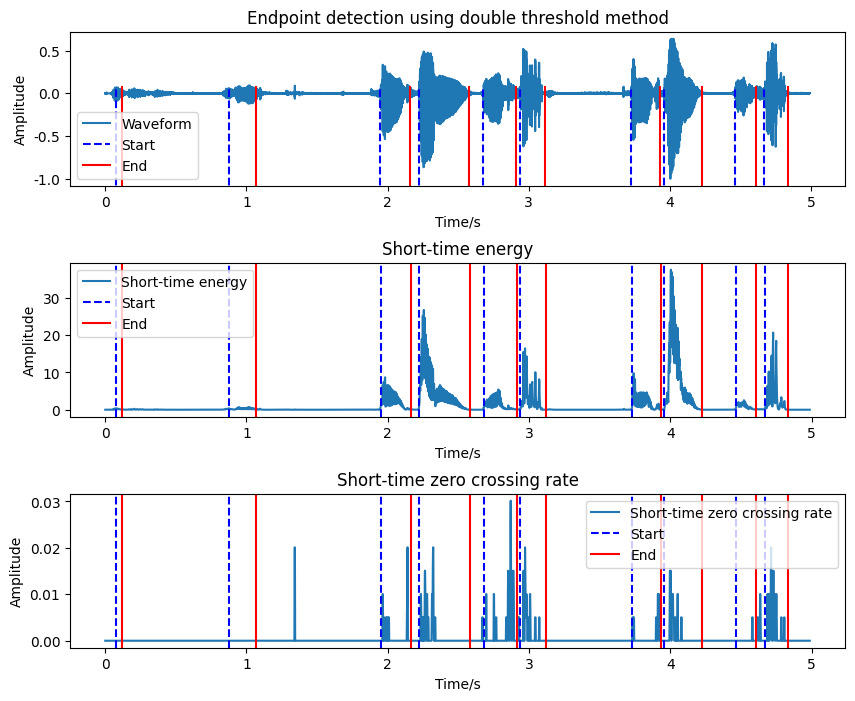

In [9]:
(fs, data) = wavfile.read('demo.wav') # 读取音频
data1 = data/np.max(np.abs(data))     # 幅值归一化

N = len(data1)
wlen = 200
inc = 80
IS = 0.1
overlap = wlen - inc
NIS = int((IS * fs - wlen) // inc + 1)
fn = (N - wlen) // inc + 1

frameTime = FrameTimeC(fn, wlen, inc, fs) # 计算每帧的时间刻度
time = [i / fs for i in range(N)]

voiceseg, vsl, SF, NF, amp, zcr = vad_TwoThr(data1, wlen, inc, NIS) # 语音段检测

# 打印语音段信息
fig, axs = plt.subplots(3, 1, figsize=(10, 8))  # Adjust figsize as needed 调整子图大小
plt.subplots_adjust(hspace=0.5)  # Adjust hspace for vertical spacing between subplots 调整子图间的垂直间距

axs[0].plot(time, data1)
axs[0].set_title('Endpoint detection using double threshold method')
axs[0].set_ylabel('Amplitude')
axs[0].set_xlabel('Time/s')

axs[1].plot(frameTime, amp)
axs[1].set_title('Short-time energy')
axs[1].set_ylabel('Amplitude')
axs[1].set_xlabel('Time/s')

axs[2].plot(frameTime, zcr)
axs[2].set_title('Short-time zero crossing rate')
axs[2].set_ylabel('Amplitude')
axs[2].set_xlabel('Time/s')

# 画出语音段的起始和终止点
for i in range(vsl):
    nx1 = voiceseg[i]['start']
    nx2 = voiceseg[i]['end']

    axs[0].axvline(frameTime[nx1], np.min(data1), np.max(data1), color='blue', linestyle='--')
    axs[0].axvline(frameTime[nx2], np.min(data1), np.max(data1), color='red', linestyle='-')
    axs[0].legend(['Waveform', 'Start', 'End'])

    axs[1].axvline(frameTime[nx1], np.min(amp), np.max(amp), color='blue', linestyle='--')
    axs[1].axvline(frameTime[nx2], np.min(amp), np.max(amp), color='red', linestyle='-')
    axs[1].legend(['Short-time energy', 'Start', 'End'])
    
    axs[2].axvline(frameTime[nx1], 0, 1, color='blue', linestyle='--')
    axs[2].axvline(frameTime[nx2], 0, 1, color='red', linestyle='-')
    axs[2].legend(['Short-time zero crossing rate', 'Start', 'End'], loc='upper right')

os.makedirs('figs', exist_ok=True) # 创建文件夹
plt.savefig('figs/vad.png') # 保存图片
plt.show()



实验1-2：基于自相关法的基音周期检测
需要补充下列方法: pitch_Corr

In [ ]:
def pitch_Corr(x, wnd, inc, T1, fs, miniL=10):
    """
    自相关法基音周期检测函数
    :param x: 语音信号
    :param wnd: 窗函数或窗长
    :param inc: 帧移
    :param T1: 门限
    :param fs: 采样率
    :param miniL: 语音段的最小帧数
    :return voiceseg, vsl, SF, Ef, period: 语音段的起始点和终止点，语音段数，语音段标记，非语音段标记，基音周期
    """
    y = enframe(x, wnd, inc)  # 补充：调用enframe方法进行分帧
    fn = y.shape[0]
    if isinstance(wnd, int):
        wlen = wnd
    else:
        wlen = len(wnd)
    voiceseg, vsl, SF, Ef = pitch_vad(x, wnd, inc, T1, miniL)  # 语音分段
    lmin = fs // 500  # 基音周期的最小值
    lmax = fs // 60  # 基音周期的最大值
    period = np.zeros(fn)
    for i in range(vsl):    # 在所有语音段中
        ixb = voiceseg[i]['start'] # 语音段的起始帧
        ixd = voiceseg[i]['duration'] # 语音段的帧数
        for k in range(ixd):
            # 补充：计算短时自相关
            yt = y[ixb + k, :]  # 提取当前帧的数据
            ru = np.correlate(yt, yt, mode='full')  # 计算自相关函数
            ru = ru[ru.size//2:]  # 只保留正延迟部分（因为自相关是对称的）
            
            # 补充：在合理范围内找到短时自相关最大值的标号作为基音周期估值
            if lmax < len(ru):
                r = ru[lmin:lmax+1]
                maxidx = np.argmax(r)
                period[ixb + k] = lmin + maxidx  # 记录基音周期
            else:
                period[ixb + k] = 0  # 如果范围超出了ru的长度，则设为0
    return voiceseg, vsl, SF, Ef, period

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

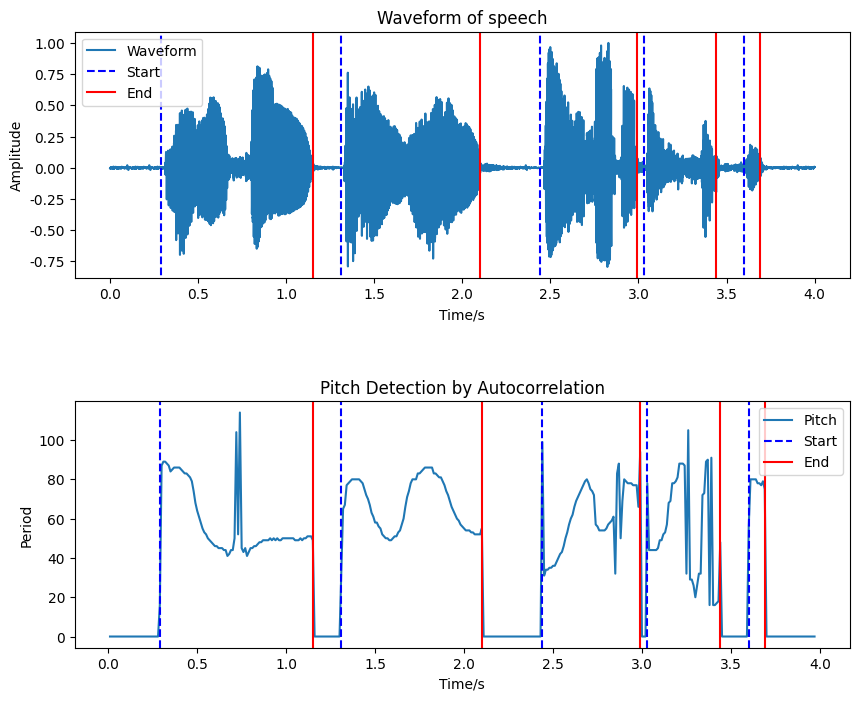

In [11]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

# 读取WAV文件
(fs, data) = wavfile.read('demo.wav')

# 去除直流偏移
data = data - np.mean(data)

# 幅值归一化
data = data / np.max(data)

# 分析参数
wlen = 320  # 分析窗口长度
inc = 80    # 连续窗口间隔
N = len(data)
time = [i / fs for i in range(N)]  # 时间向量
T1 = 0.05  # 用于基音校正的阈值

# 进行基音校正并检测有声段
voiceseg, vsl, SF, Ef, period = pitch_Corr(data, wlen, inc, T1, fs)

# 计算帧数
fn = len(SF)

# 计算帧时间位置
frameTime = FrameTimeC(fn, wlen, inc, fs)

# 设置子图布局
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
plt.subplots_adjust(hspace=0.5)  # 调整垂直间距

# 绘制波形图
axs[0].plot(time, data)
axs[0].set_title('Waveform of speech')
axs[0].set_ylabel('Amplitude')
axs[0].set_xlabel('Time/s')

# 绘制自相关基音周期检测图
axs[1].plot(frameTime, period)
axs[1].set_title('Pitch Detection by Autocorrelation')
axs[1].set_ylabel('Period')
axs[1].set_xlabel('Time/s')

# 标记有声段
for i in range(vsl):
    nx1 = voiceseg[i]['start']
    nx2 = voiceseg[i]['end']

    # 在波形图上标记有声段
    axs[0].axvline(frameTime[nx1], np.min(data), np.max(data), color='blue', linestyle='--')
    axs[0].axvline(frameTime[nx2], np.min(data), np.max(data), color='red', linestyle='-')

    # 在自相关基音周期检测图上标记有声段
    axs[1].axvline(frameTime[nx1], np.min(period), np.max(period), color='blue', linestyle='--')
    axs[1].axvline(frameTime[nx2], np.min(period), np.max(period), color='red', linestyle='-')

axs[0].legend(['Waveform', 'Start', 'End'])
axs[1].legend(['Pitch', 'Start', 'End'])

os.makedirs('figs', exist_ok=True) # 创建文件夹
plt.savefig('figs/pitch.png') # 保存图片
plt.show()





实验1-3：MFCC提取
需要补充下列方法: Nmfcc

In [ ]:
def Nmfcc(x, fs, p, frameSize, inc, nfft=512, n_dct=12):
    """
    计算MFCC (Mel-Frequency Cepstral Coefficients)系数
    MFCC是语音识别和音频特征提取中广泛使用的特征表示方法
    
    参数:
    :param x: 输入信号 - 一维数组，包含原始音频样本
    :param fs: 采样率 - 音频的采样频率，单位Hz
    :param p: Mel滤波器组的个数 - 决定了频率分辨率
    :param frameSize: 分帧的每帧长度 - 通常为20-30ms对应的样本数
    :param inc: 帧移 - 相邻帧之间的偏移量，通常为10ms对应的样本数，决定了时间分辨率
    :param nfft: FFT的长度 - 决定了频率分辨率，默认为512点
    :param n_dct: 最终保留的MFCC系数个数 - 通常取12-20，默认为12
    :return: mfcc系数 - 形状为(帧数, n_dct)的二维数组
    """
    # 步骤1: 预加重处理
    # 作用: 补偿语音信号中高频部分的衰减，增强高频成分
    # 数学表达式: y(n) = x(n) - 0.97*x(n-1)
    x_preemphasized = lfiler([1, -0.97], [1], x)  # 使用一阶FIR滤波器进行预加重
    # lfiler为线性滤波器函数，[1, -0.97]为FIR滤波器的分子系数，[1]为分母系数
    # 实际上实现了高通滤波器，传递函数H(z) = 1 - 0.97*z^(-1)

    # 步骤2: 分帧
    # 作用: 将长信号分割成短时帧，使信号在每帧内可以看作准稳态
    # 典型值: 帧长25ms，帧移10ms (对于16kHz采样率，帧长约400个样本)
    frames = enframe(x_preemphasized, frameSize, inc)  # 对预加重后的信号进行分帧
    # enframe返回形状为(帧数, 帧长)的二维数组
    # 帧数 = floor((信号长度-帧长)/帧移) + 1

    # 步骤3: 加窗
    # 作用: 减轻频谱泄漏，平滑帧的边界
    # 数学表达式: x_windowed(n) = x(n) * w(n)，其中w(n)为窗函数
    frames = np.multiply(frames, np.hanning(frameSize))  # 使用汉宁窗函数进行加窗处理
    # 汉宁窗函数: w(n) = 0.5 - 0.5*cos(2πn/(N-1))，其中N为帧长

    # 步骤4: 计算FFT (快速傅里叶变换)
    # 作用: 将时域信号转换到频域
    # 数学表达式: X(k) = Σ_{n=0}^{N-1} x(n)*e^{-j2πkn/N}
    fft_result = np.fft.rfft(frames, nfft)  # 对加窗后的帧信号进行FFT变换
    # rfft计算实数输入的FFT，只返回非负频率部分
    # fft_result形状为(帧数, nfft/2+1)，是复数数组
    # 第一列(k=0)对应直流分量，最后一列对应采样频率的一半

    # 步骤5: 计算能量谱/功率谱
    # 作用: 提取信号的能量信息
    # 数学表达式: P(k) = |X(k)|²
    power_spectrum = np.abs(fft_result) ** 2
    # power_spectrum形状为(帧数, nfft/2+1)
    # 每个元素表示对应频率分量的能量
    
    # 步骤6: 计算通过Mel滤波器的能量
    # 作用: 模拟人耳对不同频率的非线性感知
    # Mel尺度: mel(f) = 2595*log10(1+f/700)
    bank = melbankm(p, nfft, fs, 0, 0.5 * fs, 0)
    # melbankm计算Mel滤波器组矩阵，形状为(p, nfft/2+1)
    # 参数依次为: 滤波器个数，FFT点数，采样率，最低频率，最高频率，滤波器类型
    # 每一行表示一个三角形滤波器在频域中的响应
    
    ss = np.matmul(power_spectrum, bank.T)
    # 将功率谱与滤波器组相乘，得到每个Mel频带的能量
    # ss形状为(帧数, p)，即每帧信号通过p个滤波器后的能量
    # 这一步将线性频率尺度变换到更符合人耳感知的Mel频率尺度
    
    # 步骤7: 计算DCT倒谱 (离散余弦变换)
    # 作用: 去除滤波器组输出之间的相关性，实现特征压缩
    # 数学表达式: c(n) = Σ_{m=0}^{M-1} log(S(m))*cos(πn(m+0.5)/M)
    M = bank.shape[0]  # 滤波器个数，等于p
    m = np.array([i for i in range(M)])  # 创建索引数组[0,1,...,M-1]
    
    mfcc = np.zeros((ss.shape[0], n_dct))  # 初始化mfcc系数，形状为(帧数, n_dct)
    
    for n in range(n_dct):
        # 对每一帧的Mel滤波器输出取对数，然后计算DCT
        # 加1e-10是为了避免取对数时出现log(0)的情况
        # cos(πn(m+0.5)/M)是DCT-II的基函数
        mfcc[:, n] = np.sum(np.log(ss + 1e-10) * np.cos(np.pi * n * (m + 0.5) / M), axis=1)
        # 对于每一帧，计算第n个MFCC系数
        # axis=1表示沿着滤波器维度进行求和
    
    # mfcc的第0个系数(n=0)表示信号的总体能量
    # 更高阶的系数表示信号频谱的不同变化率
    # 通常在应用中，可能会省略第0个系数或对完整的MFCC系数进行归一化
    
    return mfcc  # 返回MFCC系数，形状为(帧数, n_dct)

/Users/ohhhhhmyking/Develop/anaconda3/envs/SSP/lib/python3.8/site-packages/librosa/feature/spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans

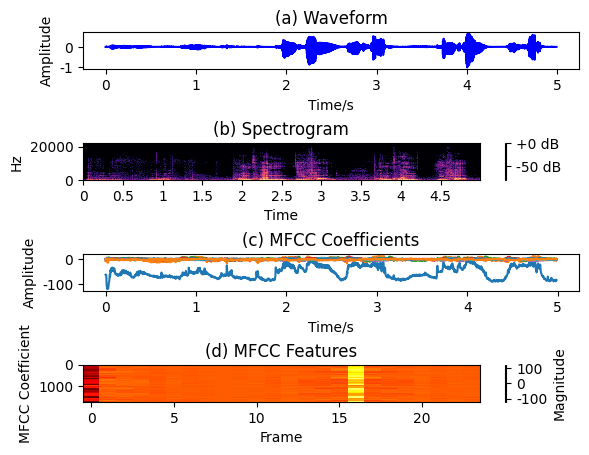

In [ ]:
import librosa
import matplotlib.pyplot as plt
from scipy.io import wavfile
import numpy as np

# 读取WAV文件
(framerate, wave_data) = wavfile.read("demo.wav")

# 参数设置
wlen = 256      # 窗口长度/帧长，单位:样本数 (例如: 对于16kHz的采样率，256对应16ms)
inc = 128       # 帧移，单位:样本数 (例如: 对于16kHz的采样率，128对应8ms)
num = 8         # Mel滤波器组个数，决定了频率分辨率
nfft = 256      # FFT的长度，通常设置为帧长或帧长的下一个2的幂
n_dct = 24      # 最终保留的MFCC系数个数

# 归一化处理
x = wave_data / max(np.abs(wave_data))
time = np.arange(0, len(wave_data)) / framerate

# 绘制原始波形
plt.figure(1)
plt.subplot(411)
plt.plot(time, x, 'b')
plt.title("(a) Waveform")
plt.ylabel("Amplitude")
plt.xlabel("Time/s")

# 计算MFCC特征
ccc1 = librosa.feature.mfcc(y=x,
                            n_fft=wlen,
                            sr=framerate,
                            n_mfcc=24,
                            fmax=4000,
                            dct_type=2,
                            hop_length=inc,
                            win_length=wlen)
ccc2 = np.transpose(ccc1)

# 进行NMFCC计算
ccc1 = Nmfcc(x, framerate, num, wlen, inc, nfft, n_dct)
fn = ccc1.shape[0]
cn = ccc1.shape[1]
frameTime = FrameTimeC(fn, wlen, inc, framerate)

# # 计算语谱图
D = librosa.stft(x, n_fft=wlen, hop_length=inc)
D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
# 绘制语谱图
plt.subplot(412)
librosa.display.specshow(D_db, sr=framerate, hop_length=inc, x_axis='time', y_axis='linear')
plt.title("(b) Spectrogram")
plt.colorbar(format='%+2.0f dB')

# 绘制MFCC系数
plt.subplot(413)
plt.plot(frameTime, ccc1[:, 0:int(cn/2)])
plt.title("(c) MFCC Coefficients")
plt.ylabel("Amplitude")
plt.xlabel("Time/s")


# 绘制MFCC特征图
plt.subplot(414)
plt.imshow(ccc1, cmap='hot', interpolation='nearest', aspect='auto')
plt.xlabel('Frame')
plt.ylabel('MFCC Coefficient')
plt.title('(d) MFCC Features')
plt.colorbar(label='Magnitude')

# 调整子图间距
plt.subplots_adjust(hspace=2)

os.makedirs('figs', exist_ok=True) # 创建文件夹
plt.savefig('figs/mfcc.png') # 保存图片
plt.show()